# Sequence Generation Algorithm from https://arxiv.org/abs/2005.05581

In [1]:
import numpy as np
from typing import List
import heapq
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import builtins
import copy
from qiskit.quantum_info import random_unitary
import matplotlib as mpl

# Logical Base Gate Sets

In [2]:
def cost_function1(n: int) -> int:
    return (4 - 3*2**(3-n))

In [3]:
def rz_gate(theta: float):
    return np.array([[np.exp(-1j * theta/2), 0], [0, np.exp(1j * theta/2)]])

In [4]:
# Creating the Tau gate sets
def odd_k(denom: int) -> List[int]:
    k_list = []
    highest = denom//2 - 1
    k_list = list(range(-highest, highest+1, 2))
    return k_list
    
def tau_set(n: int):
    tau = []
    denom = 2**(n-1)
    k_list = odd_k(denom)
    cost = cost_function1(n)
    for k in k_list:
        gate = rz_gate(k*np.pi/denom)
        tau.append({"gate": gate, "cost": cost, "name": f"Rz({k}*π/{denom})"})
    return tau

In [5]:
# Creating the logical base gate set number 1
set1 = []

pauli_x = np.array([[0, 1], [1, 0]])
set1.append({"gate": pauli_x, "cost": 0, "name": "X"})

pauli_y = np.array([[0, -1j], [1j, 0]])
set1.append({"gate": pauli_y, "cost": 0, "name": "Y"})

pauli_z = np.array([[1, 0], [0, -1]])
set1.append({"gate": pauli_z, "cost": 0, "name": "Z"})

hadamard = 1/np.sqrt(2) * np.array([[1, 1], [1, -1]])
set1.append({"gate": hadamard, "cost": 0, "name": "H"})

s_gate = rz_gate(np.pi/2)
set1.append({"gate": s_gate, "cost": 0, "name": "S"})

sdg_gate = rz_gate(-np.pi/2)
set1.append({"gate": sdg_gate, "cost": 0, "name": "Sdg"})

set1 = set1 + tau_set(3)
print(set1)

[{'gate': array([[0, 1],
       [1, 0]]), 'cost': 0, 'name': 'X'}, {'gate': array([[ 0.+0.j, -0.-1.j],
       [ 0.+1.j,  0.+0.j]]), 'cost': 0, 'name': 'Y'}, {'gate': array([[ 1,  0],
       [ 0, -1]]), 'cost': 0, 'name': 'Z'}, {'gate': array([[ 0.70710678,  0.70710678],
       [ 0.70710678, -0.70710678]]), 'cost': 0, 'name': 'H'}, {'gate': array([[0.70710678-0.70710678j, 0.        +0.j        ],
       [0.        +0.j        , 0.70710678+0.70710678j]]), 'cost': 0, 'name': 'S'}, {'gate': array([[0.70710678+0.70710678j, 0.        +0.j        ],
       [0.        +0.j        , 0.70710678-0.70710678j]]), 'cost': 0, 'name': 'Sdg'}, {'gate': array([[0.92387953+0.38268343j, 0.        +0.j        ],
       [0.        +0.j        , 0.92387953-0.38268343j]]), 'cost': 1, 'name': 'Rz(-1*π/4)'}, {'gate': array([[0.92387953-0.38268343j, 0.        +0.j        ],
       [0.        +0.j        , 0.92387953+0.38268343j]]), 'cost': 1, 'name': 'Rz(1*π/4)'}]


In [6]:
# Creating the other logical base sets
set2 = set1 + tau_set(4)
set3 = set2 + tau_set(5)
set4 = set3 + tau_set(6)
set5 = set4 + tau_set(7)

In [12]:
def remove_global_phase(U, tol=1e-12):
    """
    det = np.linalg.det(U)
    if (det == 0):
        return U
    elif (det < 0):
        s = 1j * np.sqrt(abs(det))
    else:
        s = np.sqrt(det)
        
    return U / s
    """
    det = np.linalg.det(U)
    if abs(det) < tol or det == 0:
        return U
    else:
        return U / np.exp(1j*np.angle(det)/2)

In [8]:
# Adding exotic magic state to set1
theta = np.arctan(np.sqrt((np.sqrt(5) - 1) / 2))
exotic_magic_state = np.array([[np.cos(theta/2), -np.sin(theta/2)], [np.sin(theta/2), np.cos(theta/2)]])
exotic_entry = {"gate": exotic_magic_state, "cost": 0, "name": "EMS"}

exotic_set1 = set1.copy()
exotic_set1.append(exotic_entry)
exotic_set2 = exotic_set1 + tau_set(4)
exotic_set3 = exotic_set2 + tau_set(5)
exotic_set4 = exotic_set3 + tau_set(6)
exotic_set5 = exotic_set4 + tau_set(7)

# Finding axis of rotation for an arbitrary single qubit unitary

In [9]:
identity = np.eye(2, dtype=complex)
print(identity)

[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]


In [13]:
def Lie_generator(U, eps: float = 1e-12):
    if (np.array_equal(identity, U)):
        return (0, 0, 0)
    
    U = remove_global_phase(U)
    theta = 2*np.arccos(np.trace(U)/2)
    
    denom = np.sin(theta/2.0)
    if (abs(denom) < eps):
        return (0, 0, 0)
    
    n1 = 1j * np.trace(pauli_x @ U) / (2*np.sin(theta/2))
    n2 = 1j * np.trace(pauli_y @ U) / (2*np.sin(theta/2))
    n3 = 1j * np.trace(pauli_z @ U) / (2*np.sin(theta/2))
    
    alpha = np.round(np.real(theta/2 * n1), 8)
    beta = np.round(np.real(theta/2 * n2), 8)
    gamma = np.round(np.real(theta/2 * n3), 8)
    
    return (alpha, beta, gamma)

In [14]:
print(Lie_generator(pauli_x))

(1.57079633, 0.0, 0.0)


In [15]:
def key_from_U(U: np.ndarray, grid: float = 1e-7):
    a,b,c = Lie_generator(U)
    return (np.round(a/grid), np.round(b/grid), np.round(c/grid))

In [16]:
print(key_from_U(pauli_x))

(15707963.0, 0.0, 0.0)


# Sequence Database

In [17]:
class SequenceDB:
    def __init__(self):
        self.vecs = []   # (α,β,γ)
        self.units = []  # 2x2 array
        self.costs = []
        self.seqs = []
        self.magic_count = []
        
    def add(self, v, U, cost, seq, magic_count):
        self.vecs.append(tuple(float(x) for x in v))
        self.units.append(np.array(U, dtype=complex))
        self.costs.append(float(cost))
        self.seqs.append(str(seq))
        self.magic_count.append(int(magic_count))

# Sequence Generating Algorithm

In [ ]:
# Faster Version, not incremental
# Given a base gate set and a max cost, this functions finds all the possible combinations of gates that has a T-cost of less than or equal to the max cost. 
def generate_sequences(base_gate_set, max_cost: float):
    db = SequenceDB()
    
    nodes_U = [identity]
    nodes_seq = [""]
    heap = [(0.0, 0)] # (cost, gate sequence length)
    unique = builtins.set()
    best_cost = {key_from_U(identity): 0.0}
    
    while heap:
        cost_i, i = heapq.heappop(heap)
        if (cost_i > max_cost):
            continue
        
        key_i = key_from_U(nodes_U[i])
        if key_i in unique:
            continue
        unique.add(key_i)
        
        v_i = Lie_generator(nodes_U[i])
            
        db.add(v_i, nodes_U[i], cost_i, nodes_seq[i])
        
        for base_gate in base_gate_set:
            new_cost = cost_i + base_gate["cost"]
            if (new_cost > max_cost):
                continue
            
            U_child = base_gate["gate"] @ nodes_U[i]
            key_c = key_from_U(U_child)
            
            if new_cost < best_cost.get(key_c, float("inf")):
                best_cost[key_c] = new_cost
                nodes_U.append(U_child)
                nodes_seq.append(nodes_seq[i] + base_gate["name"])
                heapq.heappush(heap, (new_cost, len(nodes_U)-1))
            
    return db

In [ ]:
# Incremental
# Given a base gate set, a lower cost (with previous db, heap, unique, and best_cost) and a max cost, this functions finds all the possible combinations of gates that has a T-cost of less than or equal to the max cost. 
def generate_sequences(base_gate_set, max_cost: float, state=None):
    if state is None:
        state = {}
        state["db"] = SequenceDB()
        state["nodes_U"] = [identity]
        state["nodes_seq"] = [""]
        state["heap"] = [(0.0, 0)]  # (cost, node_id)
        state["unique"] = builtins.set()    
        state["best_cost"] = { key_from_U(identity): 0.0 }

    db = state["db"]
    nodes_U = state["nodes_U"]
    nodes_seq = state["nodes_seq"]
    heap = state["heap"]
    unique = state["unique"]
    best_cost = state["best_cost"]
    
    while (heap and heap[0][0] <= max_cost):
        cost_i, i = heapq.heappop(heap)
        if (cost_i > max_cost):
            continue
        
        key_i = key_from_U(nodes_U[i])
        if key_i in unique:
            continue
        unique.add(key_i)
        
        v_i = Lie_generator(nodes_U[i])
            
        db.add(v_i, nodes_U[i], cost_i, nodes_seq[i])
        
        for base_gate in base_gate_set:
            new_cost = cost_i + base_gate["cost"]
            """if (new_cost > max_cost):
                continue"""
            
            U_child = base_gate["gate"] @ nodes_U[i]
            key_c = key_from_U(U_child)
            
            if new_cost < best_cost.get(key_c, float("inf")):
                best_cost[key_c] = new_cost
                nodes_U.append(U_child)
                nodes_seq.append(nodes_seq[i] + base_gate["name"])
                heapq.heappush(heap, (new_cost, len(nodes_U)-1))
            
    return state

In [14]:
# Incremental
# Given a base gate set, a lower cost (with previous db, heap, unique, and best_cost) and a max cost, this functions finds all the possible combinations of gates that has a T-cost of less than or equal to the max cost. 
def generate_sequences(base_gate_set, max_cost: float, max_magic: int, state=None):
    if state is None:
        state = {}
        state["db"] = SequenceDB()
        state["nodes_U"] = [identity]
        state["nodes_seq"] = [""]
        state["heap"] = [(0.0, 0, 0)]  # (cost, node_id, magic_num)
        state["unique"] = builtins.set()    
        state["best_cost"] = { key_from_U(identity): 0.0 }

    db = state["db"]
    nodes_U = state["nodes_U"]
    nodes_seq = state["nodes_seq"]
    heap = state["heap"]
    unique = state["unique"]
    best_cost = state["best_cost"]
    
    while (heap and heap[0][0] <= max_cost and heap[0][2] <= max_magic):
        cost_i, i, magic_i = heapq.heappop(heap)
        if (cost_i > max_cost or magic_i > max_magic):
            continue
        
        key_i = key_from_U(nodes_U[i])
        if key_i in unique:
            continue
        unique.add(key_i)
        
        v_i = Lie_generator(nodes_U[i])
            
        db.add(v_i, nodes_U[i], cost_i, nodes_seq[i], magic_i)
        
        for base_gate in base_gate_set:
            new_cost = cost_i + base_gate["cost"]
            
            if (base_gate["name"] == "EMS" or base_gate["cost"] > 0):
                new_magic = magic_i + 1
            else:
                new_magic = magic_i
            
            U_child = base_gate["gate"] @ nodes_U[i]
            key_c = key_from_U(U_child)
            
            if (new_cost < best_cost.get(key_c, float("inf")) or new_magic < max_magic):
                best_cost[key_c] = new_cost
                nodes_U.append(U_child)
                nodes_seq.append(nodes_seq[i] + base_gate["name"])
                heapq.heappush(heap, (new_cost, len(nodes_U)-1, new_magic))
            
    return state

In [ ]:
#state1_15 = generate_sequences(set1, 15, 15)
#state2 = generate_sequences(set2, 10, 100)
#state3 = generate_sequences(set3, 10, 100)
#state4 = generate_sequences(set4, 10)
#state5 = generate_sequences(set5, 10)

/opt/miniconda3/lib/python3.13/site-packages/numpy/linalg/linalg.py:2180: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)


In [ ]:
state1_20 = generate_sequences(set1, 20, 20)

/opt/miniconda3/lib/python3.13/site-packages/numpy/linalg/linalg.py:2180: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)


In [15]:
db2 = generate_sequences(set2, 10, 100)

In [16]:
db3 = generate_sequences(set3, 10, 100)

In [61]:
exotic_db1_cost0 = generate_sequences(exotic_set1, 0, 6)

/opt/miniconda3/lib/python3.13/site-packages/numpy/linalg/linalg.py:2180: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)


In [62]:
exotic_db1_cost1 = generate_sequences(exotic_set1, 1, 6, copy.deepcopy(exotic_db1_cost0))

In [71]:
exotic_state1 = generate_sequences(exotic_set1, 10, 6, copy.deepcopy(exotic_db1_cost9))

# Saving Results

In [18]:
import pickle, gzip
from pathlib import Path

In [19]:
def save_db_pickle(db, path: str):
    payload = {
        "vecs":  np.asarray(db.vecs,  dtype=float),     # (N,3)
        "units": np.asarray(db.units, dtype=complex),   # (N,2,2)
        "costs": np.asarray(db.costs, dtype=float),     # (N,)
        "seqs":  np.asarray(db.seqs,  dtype=object),    # (N,)
        "magic_count": np.asarray(db.magic_count, dtype=int)
    }
    with gzip.open(path, "wb") as f:
        pickle.dump(payload, f, protocol=pickle.HIGHEST_PROTOCOL)

def load_db_pickle(path: str) -> SequenceDB:
    with gzip.open(path, "rb") as f:
        d = pickle.load(f)
    db = SequenceDB()
    db.vecs  = [tuple(map(float, v)) for v in np.asarray(d["vecs"])]
    db.units = [np.array(U, dtype=complex) for U in np.asarray(d["units"])]
    db.costs = [float(c) for c in np.asarray(d["costs"])]
    db.seqs  = [str(s) for s in np.asarray(d["seqs"])]
    db.magic_count = [int(c) for c in np.asarray(d["magic_count"])]
    return db

In [20]:
path1 = Path.cwd() / "seqdb_set1_T18.pkl.gz"
path2 = Path.cwd() / "seqdb_set2_T10.pkl.gz"
path3 = Path.cwd() / "seqdb_set3_T10.pkl.gz"
path4 = Path.cwd() / "seqdb_set4_T10.pkl.gz"
path5 = Path.cwd() / "seqdb_set5_T10.pkl.gz"

e_path1 = Path.cwd() / "seqdb_exotic_set1_T10.pkl.gz"
e_path2 = Path.cwd() / "seqdb_exotic_set2_T10.pkl.gz"
e_path3 = Path.cwd() / "seqdb_exotic_set3_T10.pkl.gz"
"""
e_path4 = Path.cwd() / "seqdb_exotic_set4_T10.pkl.gz"
e_path5 = Path.cwd() / "seqdb_exotic_set5_T10.pkl.gz"
"""

'\ne_path4 = Path.cwd() / "seqdb_exotic_set4_T10.pkl.gz"\ne_path5 = Path.cwd() / "seqdb_exotic_set5_T10.pkl.gz"\n'

In [21]:
# Save data 
save_db_pickle(db1, path1)
#save_db_pickle(db2, path2)
#save_db_pickle(db3, path3)
#save_db_pickle(db4, path4)
#save_db_pickle(db5, path5)

#save_db_pickle(exotic_db1, e_path1)
#save_db_pickle(exotic_db2, e_path2)
#save_db_pickle(exotic_db3, e_path3)
#save_db_pickle(exotic_db4, e_path4)
#save_db_pickle(exotic_db5, e_path5)

In [21]:
# Unload data
db1 = load_db_pickle(path1)
#db2 = load_db_pickle(path2)
#db3 = load_db_pickle(path3)
#db4 = load_db_pickle(path4)
#db5 = load_db_pickle(path5)

exotic_db1 = load_db_pickle(e_path1)
#exotic_db2 = load_db_pickle(e_path2)
#exotic_db3 = load_db_pickle(e_path3)
#exotic_db4 = load_db_pickle(e_path4)
#exotic_db5 = load_db_pickle(e_path5)

# Finding Neighbors

In [30]:
def graph_distance(S, G) -> float:
    S_dagger = S.conj().T
    answer = np.sqrt((2 - abs(np.trace(S_dagger @ G))) / 2)
    answer = np.round(answer, 8)
    return answer

In [31]:
def random_rotations():
    unitary = np.array(random_unitary(2))
    unitary = remove_global_phase(unitary)
    vector = Lie_generator(unitary)
    vector = [np.asarray(vector, dtype=float)]
    return unitary, vector 

In [32]:
# Given epsilon, find the 500 nearest neighbors, and find the lowest cost one
def lowest_cost_neighbor(db, nn, random_matrix, random_vector, epsilon):
    euclidean_dist, idxs = nn.kneighbors(random_vector, 500, return_distance=True)

    T_cost_list = []
    graph_dist_list = []
    for i in idxs[0]:
        temp = graph_distance(db.units[i], random_matrix)
        if (temp <= epsilon):
            T_cost_list.append(db.costs[i])
            graph_dist_list.append(temp)
    
    T_cost_list = np.array(T_cost_list)
    if (T_cost_list.size == 0):
        return 0, 0
    else:
        min_index = np.argmin(T_cost_list)

        graph_dist = graph_dist_list[min_index]
        x = -np.log10(graph_dist)
        lowest_T_cost = T_cost_list[min_index]
        
        return x, lowest_T_cost

In [51]:
# Given epsilon, find the 500 nearest neighbors, and find the one with the lowest number of magic states
def lowest_cost_neighbor_exotic(db, nn, random_matrix, random_vector, epsilon):
    euclidean_dist, idxs = nn.kneighbors(random_vector, 500, return_distance=True)

    magic_count_list = []
    graph_dist_list = []
    op_string_list = []
    for i in idxs[0]:
        temp = graph_distance(db.units[i], random_matrix)
        if (temp <= epsilon):
            magic_count_list.append(db.magic_count[i])
            graph_dist_list.append(temp)
            op_string_list.append(db.seqs[i])
    
    magic_count_list = np.array(magic_count_list)
    if (magic_count_list.size == 0):
        return 0, 0, 0
    else:
        min_index = np.argmin(magic_count_list)

        graph_dist = graph_dist_list[min_index]
        op_string = op_string_list[min_index]
        #x = -np.log10(graph_dist)
        lowest_magic_count = magic_count_list[min_index]
        
        #return x, lowest_magic_count
        return graph_dist, lowest_magic_count, op_string

In [36]:
def db_to_graph(db):
    V = np.asarray(db.vecs, dtype=float)
    #nn = NearestNeighbors(n_neighbors=k, algorithm="kd_tree", metric="euclidean")
    nn = NearestNeighbors(algorithm="kd_tree", metric="euclidean")
    nn.fit(V)
    return nn

# Plotting

In [35]:
nn1 = db_to_graph(db1)
#nn2 = db_to_graph(db2)
#nn3 = db_to_graph(db3)
#nn4 = db_to_graph(db4)
#nn5 = db_to_graph(db5)

exotic_nn1 = db_to_graph(exotic_db1)
#exotic_nn2 = db_to_graph(exotic_db2)
#exotic_nn3 = db_to_graph(exotic_db3)

In [34]:
# Plotting db1 and exotic_db1, y-axis is average number of magic states
epsilon_list = [0.050, 0.040, 0.030, 0.025, 0.02, 0.015, 0.014, 0.012]
num_random_rotations = 500
db_list = [db1, exotic_db1]
nn_list = [nn1, exotic_nn1]
labels = ["Set1", "Exotic Set1"]

y_axis = []
y_axis_unc = []
x_axis = []
for i, db in enumerate(db_list):
    y_set = []
    y_set_unc = []
    x_set = []
    for epsilon in epsilon_list:
            x_list = []
            magic_count_list = []
            for j in range(num_random_rotations):
                random_matrix, random_vector = random_rotations()
            
                graph_dist, lowest_magic_count = lowest_cost_neighbor_exotic(db, nn_list[i], random_matrix, random_vector, epsilon)
                if (graph_dist == 0 and lowest_magic_count == 0):
                    raise ValueError(f"Gate sequencing algorithm doensn't provide a unitary that is equal or closer to {epsilon} for {i}th component in db_list")
                
                x_list.append(graph_dist)
                magic_count_list.append(lowest_magic_count)
                
            estimated_mean_x = np.asarray(x_list).mean()
            estimated_mean_magic_count = np.asarray(magic_count_list).mean()
            
            running_sum = 0
            for l in range(num_random_rotations):
                running_sum += (magic_count_list[l] - estimated_mean_magic_count)**2
            variance_mean_magic = running_sum / (num_random_rotations*(num_random_rotations-1))
            
            x_set.append(1/estimated_mean_x)
            y_set.append(estimated_mean_magic_count)
            y_set_unc.append(np.sqrt(variance_mean_magic))
            
    y_axis.append(y_set)
    y_axis_unc.append(y_set_unc)
    x_axis.append(x_set)

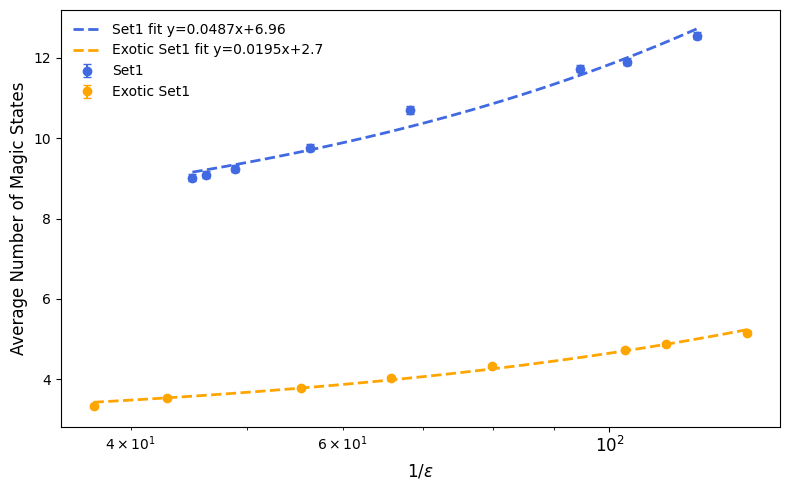

In [35]:
colors = ['royalblue', 'orange']
plt.figure(figsize=(8, 5))
for i, label in enumerate(labels):
    plt.errorbar(x_axis[i], y_axis[i], yerr=y_axis_unc[i], label=f'{label}', linestyle='none', fmt='o', capsize=3, color=colors[i])
    
    (p, cov) = np.polyfit(x_axis[i], y_axis[i], 1, w=1/np.asarray(y_axis_unc[i]), cov='unscaled')
    m, b = p
    m_err, b_err = np.sqrt(np.diag(cov))
    x_fit = np.linspace(np.asarray(x_axis[i]).min(), np.asarray(x_axis[i]).max(), 100)
    y_fit = m * x_fit + b
    plt.plot(x_fit, y_fit, linewidth=2, label=f"{label} fit y={m:.3g}x+{b:.3g}", color=colors[i], linestyle='--')

plt.legend(frameon=False, handlelength=2, loc="best", ncol=1)
plt.xlabel(r"$1/\epsilon$", size=12)
plt.ylabel("Average Number of Magic States", size=12)
plt.xscale('log')
plt.xticks(fontsize=12)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

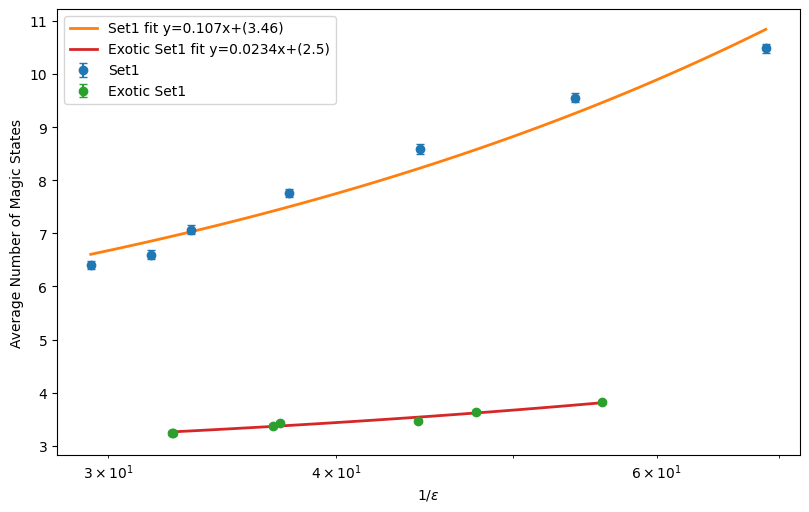

In [ ]:
# Plotting db1 and exotic_db1, y-axis is average number of magic states
epsilon_list = [0.050, 0.045, 0.040, 0.035, 0.030, 0.025, 0.02]
num_random_rotations = 500
db_list = [db1, exotic_db1]
nn_list = [nn1, exotic_nn1]
labels = ["Set1", "Exotic Set1"]

plt.figure(figsize=(8, 5))
for i, db in enumerate(db_list):
    x_axis = []
    y_axis = []
    y_unc = []
    if (i == 0):
        for epsilon in epsilon_list:
            x_list = []
            magic_count_list = []
            for j in range(num_random_rotations):
                random_matrix, random_vector = random_rotations()
            
                #x_db, lowest_magic_count = lowest_cost_neighbor_exotic(db, nn_list[i], random_matrix, random_vector, epsilon)
                graph_dist, lowest_magic_count = lowest_cost_neighbor_exotic(db, nn_list[i], random_matrix, random_vector, epsilon)
                if (graph_dist == 0 and lowest_magic_count == 0):
                    raise ValueError(f"Gate sequencing algorithm doensn't provide a unitary that is equal or closer to {epsilon}")
                
                #x_list.append(x_db)
                x_list.append(graph_dist)
                magic_count_list.append(lowest_magic_count)
                
            estimated_mean_x = np.asarray(x_list).mean()
            estimated_mean_magic_count = np.asarray(magic_count_list).mean()
            
            running_sum = 0
            for l in range(num_random_rotations):
                running_sum += (magic_count_list[l] - estimated_mean_magic_count)**2
            variance_mean_magic = running_sum / (num_random_rotations*(num_random_rotations-1))
            
            x_axis.append(1/estimated_mean_x)
            y_axis.append(estimated_mean_magic_count)
            y_unc.append(np.sqrt(variance_mean_magic))
    else:
        for epsilon in exotic_epsilon_list:
            x_list = []
            magic_count_list = []
            for j in range(num_random_rotations):
                random_matrix, random_vector = random_rotations()
            
                #x_db, lowest_magic_count = lowest_cost_neighbor_exotic(db, nn_list[i], random_matrix, random_vector, epsilon)
                graph_dist, lowest_magic_count = lowest_cost_neighbor_exotic(db, nn_list[i], random_matrix, random_vector, epsilon)
                if (graph_dist == 0 and lowest_magic_count == 0):
                    raise ValueError(f"Exotic: Gate sequencing algorithm doensn't provide a unitary that is equal or closer to {epsilon}")
                
                #x_list.append(x_db)
                x_list.append(graph_dist)
                magic_count_list.append(lowest_magic_count)
                
            estimated_mean_x = np.asarray(x_list).mean()
            estimated_mean_magic_count = np.asarray(magic_count_list).mean()
            
            running_sum = 0
            for l in range(num_random_rotations):
                running_sum += (magic_count_list[l] - estimated_mean_magic_count)**2
            variance_mean_magic = running_sum / (num_random_rotations*(num_random_rotations-1))
            
            x_axis.append(1/estimated_mean_x)
            y_axis.append(estimated_mean_magic_count)
            y_unc.append(np.sqrt(variance_mean_magic))
    
    plt.errorbar(x_axis, y_axis, yerr=y_unc, label=f'{labels[i]}', linestyle='none', fmt='o', capsize=3)
    
    (p, cov) = np.polyfit(x_axis, y_axis, 1, w=1/np.asarray(y_unc), cov='unscaled')
    m, b = p
    m_err, b_err = np.sqrt(np.diag(cov))
    x_fit = np.linspace(np.asarray(x_axis).min(), np.asarray(x_axis).max(), 100)
    y_fit = m * x_fit + b
    plt.plot(x_fit, y_fit, linewidth=2, label=f"{labels[i]} fit y={m:.3g}x+({b:.3g})")

plt.legend()
plt.tight_layout()
#plt.xlabel(r"$-\log_{10}(\epsilon)$")
plt.xlabel(r"$1/\epsilon$")
plt.ylabel("Average Number of Magic States")
plt.xscale('log')
plt.show()

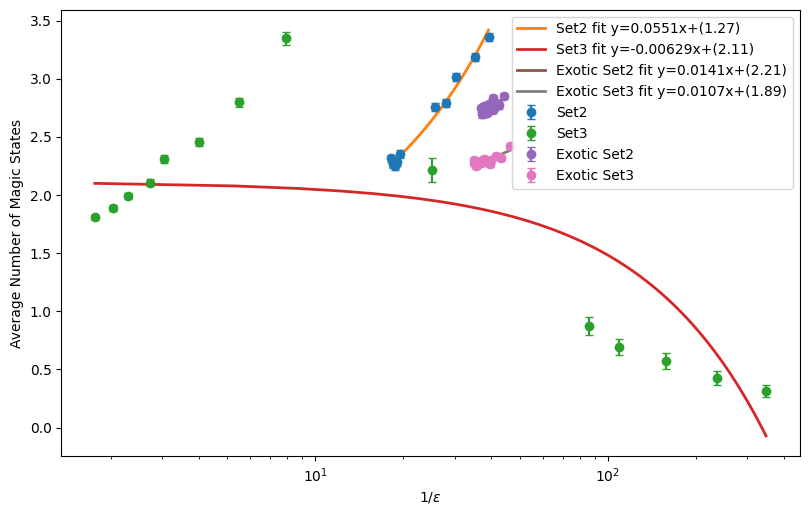

In [69]:
# Plotting db2, db3, exotic_db2, and exotic_db3, y-axis is average number of magic states
epsilon_list = [0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1, 0.060, 0.055, 0.050, 0.045, 0.040]
exotic_epsilon_list = [900, 800, 700, 600, 500, 400, 300, 200, 100, 0.060, 0.055, 0.050, 0.045, 0.040]
num_random_rotations = 500
db_list = [db2, db3, exotic_db2, exotic_db3]
nn_list = [nn2, nn2, exotic_nn2, exotic_nn3]
labels = ["Set2", "Set3", "Exotic Set2", "Exotic Set3"]

plt.figure(figsize=(8, 5))
for i, db in enumerate(db_list):
    x_axis = []
    y_axis = []
    y_unc = []
    if (i < 2):
        for epsilon in epsilon_list:
            x_list = []
            magic_count_list = []
            for j in range(num_random_rotations):
                random_matrix, random_vector = random_rotations()
            
                #x_db, lowest_magic_count = lowest_cost_neighbor_exotic(db, nn_list[i], random_matrix, random_vector, epsilon)
                graph_dist, lowest_magic_count = lowest_cost_neighbor_exotic(db, nn_list[i], random_matrix, random_vector, epsilon)
                
                #x_list.append(x_db)
                x_list.append(graph_dist)
                magic_count_list.append(lowest_magic_count)
                
            estimated_mean_x = np.asarray(x_list).mean()
            estimated_mean_magic_count = np.asarray(magic_count_list).mean()
            
            running_sum = 0
            for l in range(num_random_rotations):
                running_sum += (magic_count_list[l] - estimated_mean_magic_count)**2
            variance_mean_magic = running_sum / (num_random_rotations*(num_random_rotations-1))
            
            x_axis.append(1/estimated_mean_x)
            y_axis.append(estimated_mean_magic_count)
            y_unc.append(np.sqrt(variance_mean_magic))
    else:
        for epsilon in exotic_epsilon_list:
            x_list = []
            magic_count_list = []
            for j in range(num_random_rotations):
                random_matrix, random_vector = random_rotations()
            
                #x_db, lowest_magic_count = lowest_cost_neighbor_exotic(db, nn_list[i], random_matrix, random_vector, epsilon)
                graph_dist, lowest_magic_count = lowest_cost_neighbor_exotic(db, nn_list[i], random_matrix, random_vector, epsilon)
                
                #x_list.append(x_db)
                x_list.append(graph_dist)
                magic_count_list.append(lowest_magic_count)
                
            estimated_mean_x = np.asarray(x_list).mean()
            estimated_mean_magic_count = np.asarray(magic_count_list).mean()
            
            running_sum = 0
            for l in range(num_random_rotations):
                running_sum += (magic_count_list[l] - estimated_mean_magic_count)**2
            variance_mean_magic = running_sum / (num_random_rotations*(num_random_rotations-1))
            
            x_axis.append(1/estimated_mean_x)
            y_axis.append(estimated_mean_magic_count)
            y_unc.append(np.sqrt(variance_mean_magic))
            
    plt.errorbar(x_axis, y_axis, yerr=y_unc, label=f'{labels[i]}', linestyle='none', fmt='o', capsize=3)
    
    (p, cov) = np.polyfit(x_axis, y_axis, 1, w=1/np.asarray(y_unc), cov='unscaled')
    m, b = p
    m_err, b_err = np.sqrt(np.diag(cov))
    x_fit = np.linspace(np.asarray(x_axis).min(), np.asarray(x_axis).max(), 100)
    y_fit = m * x_fit + b
    plt.plot(x_fit, y_fit, linewidth=2, label=f"{labels[i]} fit y={m:.3g}x+({b:.3g})")
    
plt.legend()
plt.tight_layout()
#plt.xlabel(r"$-\log_{10}(\epsilon)$")
plt.xlabel(r"$1/\epsilon$")
plt.ylabel("Average Number of Magic States")
plt.xscale('log')
plt.show()

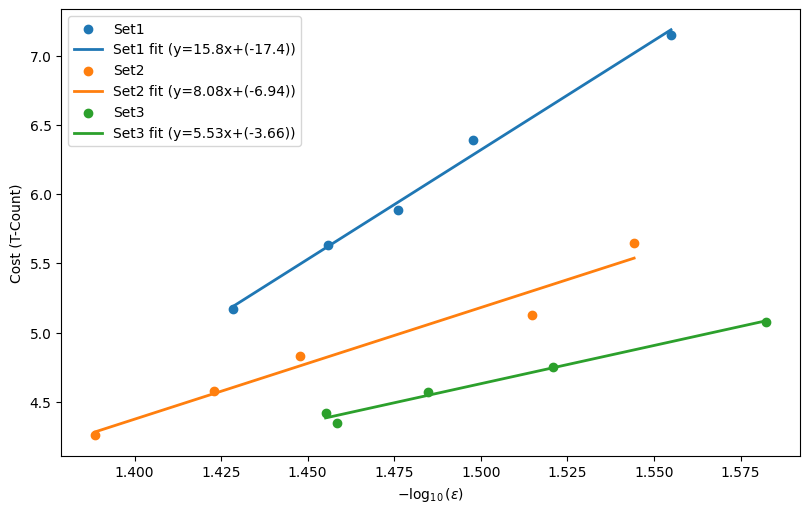

In [ ]:
# Plotting set1, set2, set3. y-axis is t-cost
db_list = [db1, db2, db3]
nn_list = [nn1, nn2, nn3]
epsilon_list = [0.060, 0.055, 0.050, 0.045, 0.040]
num_random_rotations = 500

plt.figure(figsize=(8, 5))
for i, db in enumerate(db_list):
    x_per_db = []
    t_count_per_db = []
    t_count_per_db_unc = []
    for epsilon in epsilon_list:
        x_sum = 0
        t_count_sum = 0
        x_list = []
        t_count_list = []
        for j in range(num_random_rotations):
            random_matrix, random_vector = random_rotations()

            x, lowest_T_cost = lowest_cost_neighbor(db, nn_list[i], random_matrix, random_vector, epsilon)
            x_sum += x
            t_count_sum += lowest_T_cost
            
        estimated_mean_x = np.asarray(x_list).mean()
        estimated_mean_t_count = np.asarray(t_count_list).mean()
        running_sum_t_count = 0 
        for l in range(num_random_rotations):
            running_sum_t_count += (t_count_list[l] - estimated_mean_t_count)**2
        variance_estimated_mean_t_count = running_sum_t_count / (num_random_rotations*(num_random_rotations-1))
        sdv_estimated_mean_t_count = np.sqrt(variance_estimated_mean_t_count)
        
        x_per_db.append(estimated_mean_x)
        t_count_per_db.append(estimated_mean_t_count)
        t_count_per_db_unc.append(sdv_estimated_mean_t_count)
    
    x_axis = np.array(x_per_db)
    y_axis = t_count_per_db
    
    #plt.scatter(x_axis, y_axis, label=f'Set{i+1}')
    plt.errorbar(x_axis, y_axis, yerr=t_count_per_db_unc, label=f'Set{i+1}')

    (p, cov) = np.polyfit(x_axis, y_axis, 1, w=1/np.asarray(t_count_per_db_unc), cov='unscaled')
    m, b = p
    m_err, b_err = np.sqrt(np.diag(cov))
    x_fit = np.linspace(x_axis.min(), x_axis.max(), 100)
    y_fit = m * x_fit + b
    plt.plot(x_fit, y_fit, linewidth=2, label=f"Set{i+1} fit y={m:.3g}x+({b:.3g})")

plt.legend()
plt.tight_layout()
plt.xlabel(r"$-\log_{10}(\epsilon)$")
plt.ylabel("Cost (T-Count)")
plt.show()

In [ ]:
# Plotting exotic set1, exotic set2, and exotic set3. y-axis is average number of magic states
#states = [exotic_state1]
db_list = [exotic_db1, exotic_db2, exotic_db3]
nn_list = [exotic_nn1, exotic_nn2, exotic_nn3]
epsilon_list = [0.060, 0.055, 0.050, 0.045, 0.040]
num_random_rotations = 5_000

plt.figure(figsize=(8, 5))
#for i, state in enumerate(states):
    #db = state["db"]
for i, db in enumerate(db_list):
    x_per_db = []
    magic_count_per_db = []
    for epsilon in epsilon_list:
        x_sum = 0
        magic_count_sum = 0
        for j in range(num_random_rotations):
            random_matrix, random_vector = random_rotations()

            x, lowest_magic_count = lowest_cost_neighbor_exotic(db, nn_list[i], random_matrix, random_vector, epsilon)
            x_sum += x
            magic_count_sum += lowest_magic_count
        x_per_db.append(x_sum / num_random_rotations)
        magic_count_per_db.append(magic_count_sum / num_random_rotations)
    
    x_axis = np.array(x_per_db)
    y_axis = magic_count_per_db
    
    plt.scatter(x_axis, y_axis, label=f'Exotic Set{i+1}')
    
    m, b = np.polyfit(x_axis, y_axis, 1)
    x_fit = np.linspace(x_axis.min(), x_axis.max(), 100)
    y_fit = m * x_fit + b
    plt.plot(x_fit, y_fit, label=f'Exotic Set{i+1} fit (y={m:.3g}x+({b:.3g}))', linewidth=2)

plt.legend()
plt.tight_layout()
plt.xlabel(r"$-\log_{10}(\epsilon)$")
plt.ylabel("Average Number of Magic States")
plt.show()

# Phase Estimation

In [26]:
alpha1 = -0.274220
rz_alpha1_matrix = np.array([[np.exp(-1j*alpha1/2), 0], [0, np.exp(1j*alpha1/2)]])
rz_alpha1_vector = remove_global_phase(rz_alpha1_matrix)
rz_alpha1_vector = Lie_generator(rz_alpha1_vector)
rz_alpha1_vector = [np.asarray(rz_alpha1_vector, dtype=float)]

In [81]:
epsilon_list = [0.04, 0.035, 0.03, 0.025, 0.02, 0.015, 0.014, 0.013]
db_list = [exotic_db1]
nn_list = [exotic_nn1]
labels = ["Exotic Set1"]

rz_alpha1_magic_count = []
rz_alpha1_overlap = []
op_string_list = []
for i, db in enumerate(db_list):
    y_set = []
    x_set = []
    op_string_set = []
    for epsilon in epsilon_list:
        graph_dist, lowest_magic_count, op_string = lowest_cost_neighbor_exotic(db, nn_list[i], rz_alpha1_matrix, rz_alpha1_vector, epsilon)
        if (graph_dist == 0 and lowest_magic_count == 0):
            raise ValueError(f"Gate sequencing algorithm doensn't provide a unitary that is equal or closer to {epsilon} for {i}th component in db_list")
        
        x_set.append(1/graph_dist)
        y_set.append(lowest_magic_count)
        op_string_set.append(op_string)
            
    rz_alpha1_magic_count.append(y_set)
    rz_alpha1_overlap.append(x_set)
    op_string_list.append(op_string_set)

In [87]:
op_string_list

[['HSEMSEMSSdgHSdg',
  'HSEMSEMSSdgHSdg',
  'HSEMSEMSSdgHSdg',
  'HSEMSEMSSdgHSdg',
  'HSEMSEMSSdgHSdg',
  'HSEMSEMSSdgHSdg',
  'HSEMSEMSSdgHSdg',
  'HSEMSEMSSdgHSdg']]

In [83]:
rz_alpha1_overlap

[[78.78178155545174,
  78.78178155545174,
  78.78178155545174,
  78.78178155545174,
  78.78178155545174,
  78.78178155545174,
  78.78178155545174,
  78.78178155545174]]

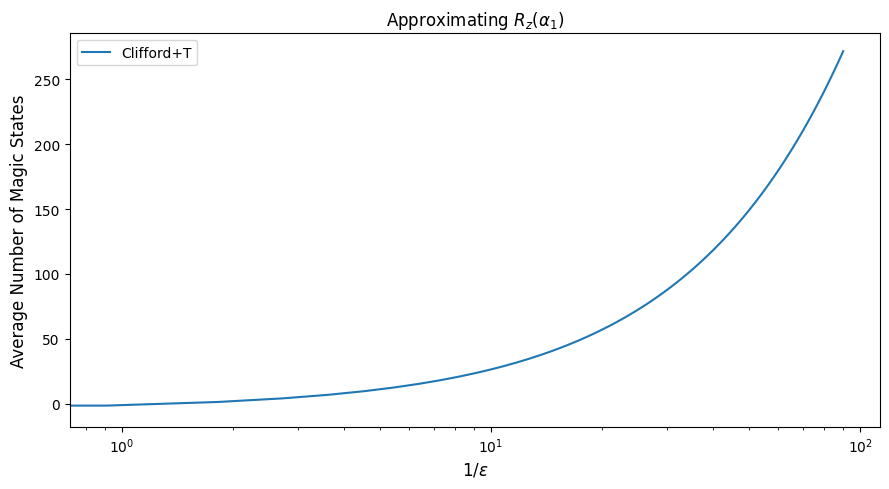

In [86]:
plt.figure(figsize=(9, 5))
#plt.plot(rz_alpha1_overlap[0], rz_alpha1_magic_count[0], label='Clifford+T+EMS')

x = np.linspace(0, 90, 100)
y_line = 3.067 * x - 4.322
plt.plot(x, y_line, label='Clifford+T')

plt.legend()
plt.xlabel(r"$1/\epsilon$", size=12)
plt.ylabel("Average Number of Magic States", size=12)
plt.xscale('log')
plt.title(r'Approximating $R_z(\alpha_1)$')
plt.tight_layout()
plt.show()

In [55]:
alpha2 = -0.785398
rz_alpha2_matrix = np.array([[np.exp(-1j*alpha2/2), 0], [0, np.exp(1j*alpha2/2)]])
rz_alpha2_vector = remove_global_phase(rz_alpha2_matrix)
rz_alpha2_vector = Lie_generator(rz_alpha2_vector)
rz_alpha2_vector = [np.asarray(rz_alpha2_vector, dtype=float)]

In [63]:
epsilon_list = [0.050, 0.040, 0.030, 0.025, 0.02, 0.015, 0.014]
db_list = [db1, exotic_db1]
nn_list = [nn1, exotic_nn1]
labels = ["Set1", "Exotic Set1"]

rz_alpha2_magic_count = []
rz_alpha2_overlap = []
op_string2_list = []
for i, db in enumerate(db_list):
    y_set = []
    x_set = []
    op_string_set = []
    for epsilon in epsilon_list:
        graph_dist, lowest_magic_count, op_string = lowest_cost_neighbor_exotic(db, nn_list[i], rz_alpha2_matrix, rz_alpha2_vector, epsilon)
        if (graph_dist == 0 and lowest_magic_count == 0):
            raise ValueError(f"Gate sequencing algorithm doensn't provide a unitary that is equal or closer to {epsilon} for {i}th component in db_list")
        
        x_set.append(1/graph_dist)
        y_set.append(lowest_magic_count)
        op_string_set.append(op_string)
            
    rz_alpha2_magic_count.append(y_set)
    rz_alpha2_overlap.append(x_set)
    op_string2_list.append(op_string_set)

In [64]:
op_string2_list

[['Rz(-1*π/4)',
  'Rz(-1*π/4)',
  'Rz(-1*π/4)',
  'Rz(-1*π/4)',
  'Rz(-1*π/4)',
  'Rz(-1*π/4)',
  'Rz(-1*π/4)'],
 ['Rz(-1*π/4)',
  'Rz(-1*π/4)',
  'Rz(-1*π/4)',
  'Rz(-1*π/4)',
  'Rz(-1*π/4)',
  'Rz(-1*π/4)',
  'Rz(-1*π/4)']]

In [65]:
rz_alpha2_overlap

[[16666666.666666668,
  16666666.666666668,
  16666666.666666668,
  16666666.666666668,
  16666666.666666668,
  16666666.666666668,
  16666666.666666668],
 [16666666.666666668,
  16666666.666666668,
  16666666.666666668,
  16666666.666666668,
  16666666.666666668,
  16666666.666666668,
  16666666.666666668]]